Accuracy: 0.3
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         4
     neutral       0.00      0.00      0.00         2
    positive       0.33      0.75      0.46         4

    accuracy                           0.30        10
   macro avg       0.11      0.25      0.15        10
weighted avg       0.13      0.30      0.18        10



[nltk_data] Downloading package stopwords to /Users/nyuad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/nyuad/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/Users/nyuad/jupyter-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nyuad/jupyter-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nyuad/jupyter-env/lib/python3.14/site-packages/sklearn/metrics/_classificat

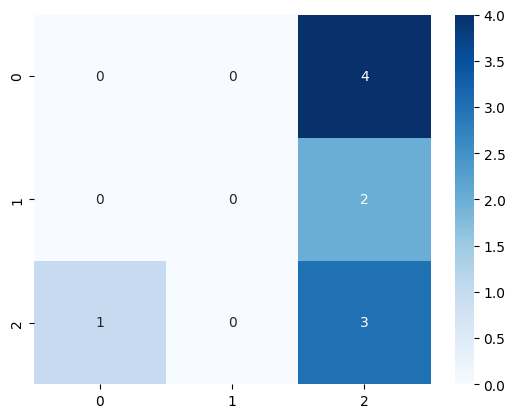

Model and vectorizer saved successfully!


In [14]:
# ---------------------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv("uae_customer_reviews.csv")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# ---------------------------------------------------------
# 3. TEXT CLEANING FUNCTION
# ---------------------------------------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['review_text'].apply(clean_text)

# ---------------------------------------------------------
# 4. FEATURES & LABELS
# ---------------------------------------------------------
X = df['clean_text']
y = df['sentiment']

# ---------------------------------------------------------
# 5. TF-IDF VECTORIZATION (Correct & Final)
# ---------------------------------------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_vec = tfidf.fit_transform(X)

# ---------------------------------------------------------
# 6. TRAIN-TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 7. TRAIN MODEL
# ---------------------------------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 8. EVALUATION
# ---------------------------------------------------------
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.show()

# ---------------------------------------------------------
# 9. SAVE MODEL + TF-IDF FOR STREAMLIT
# ---------------------------------------------------------
import joblib
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


# !pip3 install pandas

In [ ]:
!pip install matplotlib


In [ ]:
!pip install seaborn

In [ ]:
!pip3 install scikit-learn

In [12]:
!pip install nltk


In [15]:
!pip install wordcloud

In [17]:
!pip install gensim
!pip install pyLDAvis


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 18.3 MB/s  0:00:01 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [797 lines of output]
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-0ogb50q4/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-0ogb50q4/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build/lib.macosx-15.0-x86_64-cpython-314/gensim
 

In [18]:
!pip install gensim


  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached smart_open-7.6.1-py3-none-any.whl.metadata (25 kB)
  Using cached wrapt-2.1.2-cp314-cp314-macosx_10_15_x86_64.whl.metadata (7.4 kB)
Using cached smart_open-7.6.1-py3-none-any.whl (64 kB)
Using cached wrapt-2.1.2-cp314-cp314-macosx_10_15_x86_64.whl (61 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [797 lines of output]
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-84xz5le1/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-84xz5le1/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.